# Part 1. Pre-Processing

In [16]:
# Dependencies

from contextlib import contextmanager
from datetime import datetime
from datetime import date, timedelta
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
import numpy as np
import pandas as pd

import eda_starter as eda

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

from xgboost import XGBRegressor
import shap

import btc_helper as help
import polymarket_helper as poly
import requests

In [4]:
import importlib
importlib.reload(help)

<module 'btc_helper' from 'C:\\Users\\timot\\OneDrive\\Learn\\GT OMSA\\Practicum\\eda\\btc_helper.py'>

Load dataset

In [5]:
btc_df = eda.load_bitcoin_data(eda.COINMETRICS_PATH)

Loading Bitcoin data from C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 273.94 MB
[Memory] After loading Bitcoin data: 307.20 MB (Δ 33.27 MB)
Successfully loaded 6221 rows.


In [6]:
btc_df = btc_df.filter(pl.col("PriceUSD").is_not_null())

In [15]:
type(btc_df['time'][0])

datetime.datetime

Bitcoin pricing has fluctuated rapidly since its first public price of US$0.003. Its price increased by over 42 million times to a peak of USD 126,210 in 2025, followed by a 52% decline.

Text(2018-02-01, 120000, 'Backtest start')

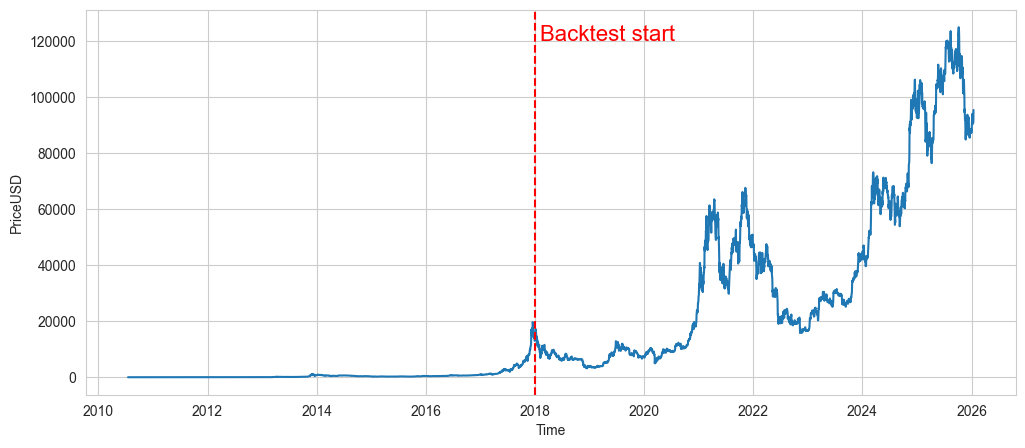

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(btc_df['time'], btc_df['PriceUSD'])
plt.xlabel('Time')
plt.ylabel('PriceUSD')
plt.axvline(x=date(2018,1,1), color='r', linestyle='--')
plt.text(date(2018,2,1), 120000, "Backtest start", fontsize=16, color='r')

## 2. Data Import and Feature Engineering

Features generated will include T = t. To avoid data leakage, all evaluation will be using time_basis column on the day before

In [157]:
# Avoid data leakage. Data seen on time_basis is everything from the day before
btc_df = btc_df.with_columns(
    pl.col("time").shift(-1).alias("time_basis"),
)

The data sources used in the project are listed in Table 1. Initial on-chain metrics from Coinmetrics and prediction market data from Polymarket were provided. To further enhance information availability, additional trading data from Binance and macro data from Federal Reserve was also imported.


| Type              | Source    | Data availability                                      |
|-------------------|----------|--------------------------------------------------------|
| On-chain          | Coinmetrics | Since 2010                                             |
| Technical         | Processed from Coinmetrics | Since 2010                                       |
| Prediction market | Polymarket | Varies. Detailed trade data only since 2025-04-07       |
| Klines daily trade| Binance  | Since 2017                                             |
| Macro             | Federal Reserve | Since 2006                                             |

### 2.1 On-Chain Metrics

Additional features were derived from existing columns to cover key aspects of the Bitcoin market including valuation, momentum, miner stress, exchange flow, volatility, and market activity

| Name                  | Description                                                                 | Category          |
|-----------------------|-----------------------------------------------------------------------------|-------------------|
| oc_MVRVCur_Z          | MVRV Z-score on a rolling 365-day period                                   | Valuation         |
| oc_MVRVCur_grad       | MVRV Z-score smoothed gradient (first derivative)                          | Momentum          |
| oc_MVRVCur_accel      | MVRV Z-score smoothed acceleration (second derivative)                     | Momentum          |
| oc_MVRV_high          | 1 if CapMrktCurUSD Z-score > 2                                             | Valuation regime  |
| oc_Puell_proxy        | Daily issuance value divided by 365-day rolling mean. Lower is better buying opportunity. | Miner stress      |
| oc_miner_stress       | HashRate divided by 365-day rolling mean                                   | Miner stress      |
| oc_netexchangenorm    | (FlowInExUSD - FlowOutExUSD) / CapMrktCurUSD                               | Exchange flow     |
| oc_flow_ratio         | (FlowInExUSD - FlowOutExUSD) / (FlowInExUSD + FlowOutExUSD)                | Exchange flow     |
| oc_MVRVCur_vol_Z      | MVRV 30-day standard deviation Z-score                                     | Volatility        |
| oc_vol_30d            | Rolling standard deviation of log returns                                  | Volatility        |
| oc_vol_30d_Z          | Z-score of oc_vol_30d                                                      | Volatility        |
| oc_turnover           | volume_reported_spot_usd_1d / CapMrktCurUSD                                | Market activity   |


In [158]:
btc_df = help.OnChainIndicators(btc_df)

### 3.2 Technical Indicators

| Name              | Description                                              | Category   |
|-------------------|----------------------------------------------------------|------------|
| sma_200           | 200-day price rolling average                           | Valuation  |
| smastd_200        | 200-day price rolling standard deviation                | Volatility |
| distance_sma_200  | Price normalized to 200-day moving average              | Valuation  |
| ema_200           | 200-day price EWMA                                      | Valuation  |
| emastd_200        | 200-day price exponential rolling standard deviation    | Volatility |
| distance_ema_200  | Price normalized to 200-day EWMA                        | Valuation  |
| drawdown          | Percentage drawdown compared to all-time-high           | Valuation  |
| RSI               | Relative strength index indicating oversold or overbought | Valuation  |
| RSI_zscore        | Z-score for RSI                                         | Valuation  |

In [159]:
btc_df = help.TechnicalIndicators(btc_df)

### 3.3 Macro Indicators

| Name                | Description                                                                 | Category      |
|---------------------|-----------------------------------------------------------------------------|---------------|
| M2SL                | Money supply to indicate liquidity cycles                                  | Macro regime  |
| WALCL               | Fed balance sheet                                                          | Macro regime  |
| fed_balance_growth  | YoY increase of WALCL                                                      | Macro regime  |
| real_rate           | DFII10 (10-Year Treasury Inflation-Indexed Constant Maturity Securities)   | Macro regime  |
| usd_strength        | DTWEXBGS (U.S. Dollar strength)                                            | Macro regime  |
| 10y_yield           | DGS10 (10-Year Treasury Constant Maturity Securities)                      | Macro regime  |
| inflation_yoy       | CPIAUCSL (Consumer Price Index)                                            | Macro regime  |

In [256]:
# Macro = help.MacroGenerator()
# Macro.load_macro_data()
# macro_df = Macro.cleanup()
# macro_df.write_parquet("macro_df.parquet", compression="zstd")


C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\eda\btc_helper.py:229: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.df["fed_balance_growth"] = self.df["WALCL"].pct_change(365)


In [160]:
macro_df = pl.read_parquet("macro_df.parquet")
btc_df = btc_df.join(macro_df, on='time', how='left')
del macro_df

### 3.4 Binance Enhancement
Additional data enhancement from crypto marketplace Binance

| Name                                                                 | Description                              | Category         |
|----------------------------------------------------------------------|------------------------------------------|------------------|
| time, open, high, low, close, volume, close_time, quote_volume, trades, taker_buy_base, taker_buy_quote, ignore | Binance Bitcoin exchange Klines dataset | Exchange         |
| funding_rate                                                        | Funding rate of Bitcoin futures          | Future exchange  |
| markPrice                                                           | Mark price of Bitcoin futures            | Future exchange  |
| bin_volatility_30d                                                  | Price rolling standard deviation         | Volatility       |
| bin_volume_zscore                                                   | Trading volume Z-score                   | Volatility       |

Funding rate: periodic payments transferred between holders of long and short positions in Perpetual Contracts

In [252]:
# bin_df = help.BinanceIndicators()
# bin_df.write_parquet("bin_df.parquet", compression="zstd")

In [161]:
bin_df = pl.read_parquet("bin_df.parquet")
btc_df = btc_df.join(bin_df, on='time', how='left')
del bin_df

### 3.5 Polymarket

In [89]:
poly_data = eda.load_polymarket_data(eda.POLYMARKET_DIR)

Loading Polymarket data from C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Polymarket...
[Memory] Before loading Polymarket data: 89.28 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
Loaded 156636 tokens records.
Loaded 27013724 trades records.
Loaded 44033 events records.
[Memory] After loading Polymarket data: 2.67 GB (Δ 2.58 GB)


In [264]:
# Overview of the polymarket data summary
eda.analyze_polymarket_summary(poly_data)


--- Polymarket Data Summary ---
Total Markets: 78321
Active Markets: 78321
Closed Markets: 0
Total Volume: $18,203,500,864.53
Average Volume per Market: $232,421.71
Total Tokens: 156636
shape: (5, 3)
┌───────────┬─────────────────────────────────┬─────────┐
│ market_id ┆ token_id                        ┆ outcome │
│ ---       ┆ ---                             ┆ ---     │
│ str       ┆ str                             ┆ str     │
╞═══════════╪═════════════════════════════════╪═════════╡
│ 240383    ┆ 555875344331027638590324435858… ┆ Yes     │
│ 240383    ┆ 111837615529992437689409005124… ┆ No      │
│ 240384    ┆ 113459643164060403919504712048… ┆ Yes     │
│ 240384    ┆ 110606609354376812966157988257… ┆ No      │
│ 240385    ┆ 505435736314143687770680977181… ┆ Yes     │
└───────────┴─────────────────────────────────┴─────────┘
Total Trades: 27013724
shape: (5, 9)
┌────────────┬───────────┬────────────┬────────────┬───┬────────────┬──────┬───────────┬───────────┐
│ trade_id   ┆ market_i

#### 3.5.1 Market Categorization
How much of it is related to Bitcoin/BTC?
* Some of the smaller categories are merged into larger ones and used as training data to categorize markets with missing category
* "Crypto" markets with questions containing "Bitcoin" or "BTC" are recategorized into separate category

In [150]:
markets_df = poly_data.get("markets")
markets_df = poly.categorize_markets(markets_df)

                    precision    recall  f1-score   support

          Business      0.750     0.913     0.824        23
            Crypto      0.986     1.000     0.993        68
   Global Politics      0.750     0.400     0.522        15
             Other      1.000     0.500     0.667         2
US-current-affairs      0.927     0.962     0.944        53

          accuracy                          0.913       161
         macro avg      0.883     0.755     0.790       161
      weighted avg      0.911     0.913     0.905       161



As a start, we can use ~26% of the *market* dataset for the Bitcoin accumulation strategy development

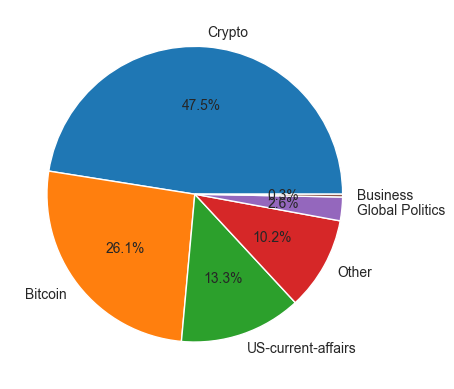

In [151]:
total = markets_df.height
top_cats = (
    markets_df.group_by("category")
    .agg(pl.count("market_id").alias("count"))
    .with_columns(
        (pl.col("count") / total * 100).alias("pct")
    )
    .sort("count", descending=True)
)
fig, ax = plt.subplots()
ax.pie(top_cats["count"], labels=top_cats["category"], autopct='%1.1f%%')
plt.show()

**Polymarket dataset**

For Bitcoin Polymarket markets dataset, the "question" column can be categorized as:
* Bullish (value: +1) if the positive answer indicates price increase (e.g. "Will BTC hit $40,000 by Halloween?", "Bitcoin all time high in Q1?")
* Bearish (value: -1) if the positive answer indicates price decrease (e.g. "BTC dips below 65k before August?")
* Neutral (value: 0) if the question does not explicitly indicate price increase/decrease (e.g. "MOG vs. BITCOIN - Most Liked Post Today", "Will RFK Jr. say "Crypto" or "Bitcoin" during Friday address?")

Initial 600 rows with validated results are used to train model to categorize the rest with high accuracy. About 70% of the questions are framed as bullish

In [91]:
markets_df_btc= poly.categorize_market_sentiment(markets_df.filter(pl.col("category")=="Bitcoin"))
del markets_df

              precision    recall  f1-score   support

     bearish      1.000     1.000     1.000        14
     bullish      0.975     0.975     0.975        79
     neutral      0.926     0.926     0.926        27

    accuracy                          0.967       120
   macro avg      0.967     0.967     0.967       120
weighted avg      0.967     0.967     0.967       120



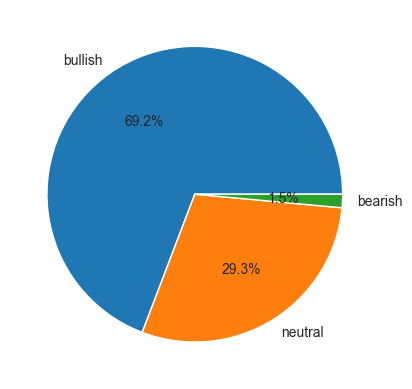

In [115]:
market_stance_cat = (
    markets_df_btc.group_by("poly_mkt_sentiment")
    .agg(pl.col("market_id").count().alias("count"))
    .sort("count", descending=True)
)

fig, ax = plt.subplots()
ax.pie(market_stance_cat["count"], labels=market_stance_cat["poly_mkt_sentiment"], autopct='%1.1f%%')
plt.show()

#### 3.5.2 Tokens categorization

In [92]:
tokens_df = poly_data.get("tokens")
tokens_df = tokens_df.join(markets_df_btc["market_id","question","poly_mkt_sentiment","poly_mkt_sentiment_dir","end_date"], on="market_id", how="left",)
tokens_df_btc = tokens_df.filter(pl.col("question").is_not_null())
tokens_df_btc = poly.categorize_token_sentiment(tokens_df_btc)
# Remove neutral questions
tokens_df_btc = tokens_df_btc.filter(pl.col("poly_mkt_sentiment")!="neutral")
del tokens_df

#### 3.5.3 Trades categorization and daily aggregation

| Name                                                                 | Description                                                                 |
|----------------------------------------------------------------------|-----------------------------------------------------------------------------|
| poly_dtrade_count                                                   | Daily number of trades                                                      |
| poly_dtrade_active_traders                                          | Daily number of traders                                                     |
| poly_dtrade_avg_trx                                                 | Daily average trade value                                                   |
| poly_dtrade_trx                                                     | Daily total trade value                                                     |
| poly_dtrade_trx_dir                                                 | Daily net trade value between bullish and bearish transactions              |
| poly_dtrade_trx_std                                                 | Daily bullish and bearish trade value standard deviation                    |
| odds_markets                                                        | Number of markets with transactions on that day                             |
| odds_avg (0 to 1)                                                   | Average adjusted token price transacted that day (1 = very bullish, 0 = bearish) |
| odds_dispersion                                                     | Token price standard deviation                                              |
| odds_breadth                                                        | Percentage of markets being bullish on that day                             |
| odds_long_market                                                    | Number of markets with end time more than 30 days out (more speculative)    |
| odds_long_avg                                                       | odds_avg for long markets                                                   |
| odds_short_market                                                   | Number of markets with end time 30 days or less (more certain)              |
| odds_short_avg                                                      | odds_avg for short markets                                                  |
| poly_dtrade_trx_zscore / poly_dtrade_trx_dir_zscore / odds_avg_zscore / odds_long_zscore / odds_short_zscore | Z-score for different metrics                              |
| poly_dtrade_trx_dir_ratio                                           | poly_dtrade_trx_dir / poly_dtrade_trx (trade imbalance)                     |

In [93]:
trades_df = poly_data.get("trades")
trades_df_btc = poly.merge_tokens_trades(tokens_df_btc, trades_df)
del trades_df
del tokens_df_btc
# Remove neutral trades (minority)
trades_df_btc = trades_df_btc.filter(pl.col("poly_trade_trx_dir")!=0)

In [94]:
trades_df_btc_daily = poly.trades_daily_agg(trades_df_btc)

Data is fairly limited, only since 2025-04-07

#### 3.5.4 Odds History
Data does not aggregate well, will not be used

In [21]:
# odds_df = poly_data.get("odds")
# test = odds_df.join(markets_df_btc, on="market_id", how="inner").filter(
#         (pl.col("question").is_not_null()) & (pl.col("poly_mkt_sentiment") != "neutral"))
# test = test.with_columns(
#         pl.when(pl.col("poly_mkt_sentiment") == "bullish").then(pl.col("price"))
#         .when(pl.col("poly_mkt_sentiment") == "bearish").then(1-pl.col("price"))
#         .alias("odds")
#     )
# test.filter(
#     pl.col("timestamp").dt.date() == pl.lit("2025-08-29").str.to_date()
# )["price"].mean()

In [61]:
# test.group_by(
#         pl.col("timestamp").dt.date().alias("time")
#     ).agg(
#         # No of markets
#         pl.col("market_id").n_unique().alias("odds_markets"),
#         pl.col("odds").mean().alias("odds_avg")
# )

time,odds_markets,odds_avg
date,u32,f64
2024-08-07,10,0.5
2024-07-26,8,0.5
2025-04-14,37,0.5
2025-09-04,147,0.5
2024-07-23,8,0.5
…,…,…
2024-07-05,9,0.5
2025-03-27,38,0.5
2024-03-05,17,0.5


In [54]:
# odds_df_btc =poly.merge_markets_odds(markets_df_btc, odds_df)
# odds_df_btc

In [39]:
# poly_data.get("summary")

market_id,question,slug,volume,active,token_count,trade_count,first_trade,last_trade
str,str,str,f64,bool,i64,i64,datetime[μs],datetime[μs]
"""798778""","""Will the price of Bitcoin be b…","""will-the-price-of-bitcoin-be-b…",8756.369075,true,2,279,2025-12-09 04:35:47,2025-12-09 12:51:41
"""893560""","""Ethereum Up or Down - December…","""eth-updown-15m-1765258200""",0.0,true,2,1274,2025-12-09 04:19:37,2025-12-09 05:42:35
"""821729""","""Will the price of Solana be ab…","""solana-above-180-on-december-1…",171.504726,true,2,8,2025-12-06 00:14:15,2025-12-09 04:37:13
"""687200""","""Will Bitcoin reach $100,000 by…","""will-bitcoin-reach-100000-by-d…",3.0088e6,true,2,6795,2025-11-26 11:11:15,2026-01-01 05:26:25
"""556062""","""MegaETH market cap (FDV) >$2B …","""megaeth-market-cap-fdv-2b-one-…",2.6813e6,true,2,1379,2025-11-26 14:52:25,2026-01-05 04:43:39
…,…,…,…,…,…,…,…,…
"""224954""","""Will it be possible to buy a T…","""will-it-be-possible-to-buy-a-t…",45525.31,true,2,0,null,null
"""628727""","""Solana Up or Down on October 1…","""solana-up-or-down-on-october-1…",29968.744483,true,2,0,null,null
"""680295""","""Bitcoin Up or Down - November …","""btc-updown-15m-1763124300""",23572.535982,true,2,0,null,null


Merge datasets

To-do: key in default values

In [162]:
btc_df = btc_df.join(trades_df_btc_daily, on='time', how='left')

### 3.6 Target metrics

Various metrics are generated

* target_up_60d: This metric is intended to capture the efficiency of buying Bitcoin today compared to sometime in the next 60 days. A categorical target was selected instead of a continuous one to reduce the impact of noisy returns.

$$
\text{target\_up\_60d} =
\begin{cases}
1, & \text{if } ROI\_{60d\_avg} > 0 \\
0, & \text{otherwise}
\end{cases}
$$

$$
ROI\_{60d\_avg} = \frac{\text{Price}_{t+1 \text{ to } t+60}}{\text{Price}_t} - 1
$$

* ROI_30d_top30: Another measure of profitability. With this metric, the ROI threshold changes with respect to whether Bitcoin has had more bull or bear periods up to the training period. Over 2010-2026, the 70th percentile ROI_30d is ~15.8%, which has high threshold of profitability.

$$
ROI\_{30d\_top30,t} =
\begin{cases}
1, & \text{if } ROI\_{30d} > \text{70th percentile of historical } ROI\_{30d} \text{ up to time } t \\
0, & \text{otherwise}
\end{cases}
$$

$$
ROI\_{30d} = \frac{\text{Price}_{t+30}}{\text{Price}_t} - 1
$$

* Future_60d_min_rel: Captures downside risk and whether there is a better window to buy in the next 60 days.

$$
\text{Future\_60d\_min\_rel} = \ln \left( \frac{\text{Average of lowest 5 prices in the next 60 days}}{\text{Price}_t} \right)
$$

In [163]:
btc_df = help.btc_target(btc_df)

### 3.7 Cleanup
Fill in the blanks

In [75]:
# Identify columns with non-zero nulls
null_counts = btc_df.null_count()
cols_with_nulls = [
    col for col in null_counts.columns
    if null_counts[col].item() > 0
]

# Select only those columns from the null count result
result = null_counts.select(cols_with_nulls)
result.transpose(include_header=True)

column,column_0
str,u32
"""CapMrktEstUSD""",3261
"""ROI1yr""",365
"""ROI30d""",30
"""ReferenceRate""",5653
"""ReferenceRateETH""",5653
…,…
"""ROI_60d_avg""",59
"""future_60d_vs_30d_SMA""",89
"""future_60d_min""",60


In [202]:
corr_df = btc_df_trunc.to_pandas()
corr = corr_df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
to_drop

['AdrBalCnt',
 'CapMrktCurUSD',
 'HashRate',
 'PriceUSD',
 'TxTfrCnt',
 'distance_sma_200',
 'emastd_200',
 'distance_ema_200',
 'drawdown',
 'M2SL',
 'WALCL',
 'CPIAUCSL',
 '10y_yield',
 'markPrice',
 'poly_dtrade_trx',
 'poly_dtrade_trx_dir',
 'poly_dtrade_trx_std',
 'odds_markets',
 'odds_breadth',
 'odds_short_market',
 'odds_short_avg',
 'poly_dtrade_trx_dir_zscore',
 'odds_long_zscore',
 'odds_short_zscore',
 'poly_dtrade_trx_dir_ratio',
 'future_30d_avg',
 'target_rank_30d']

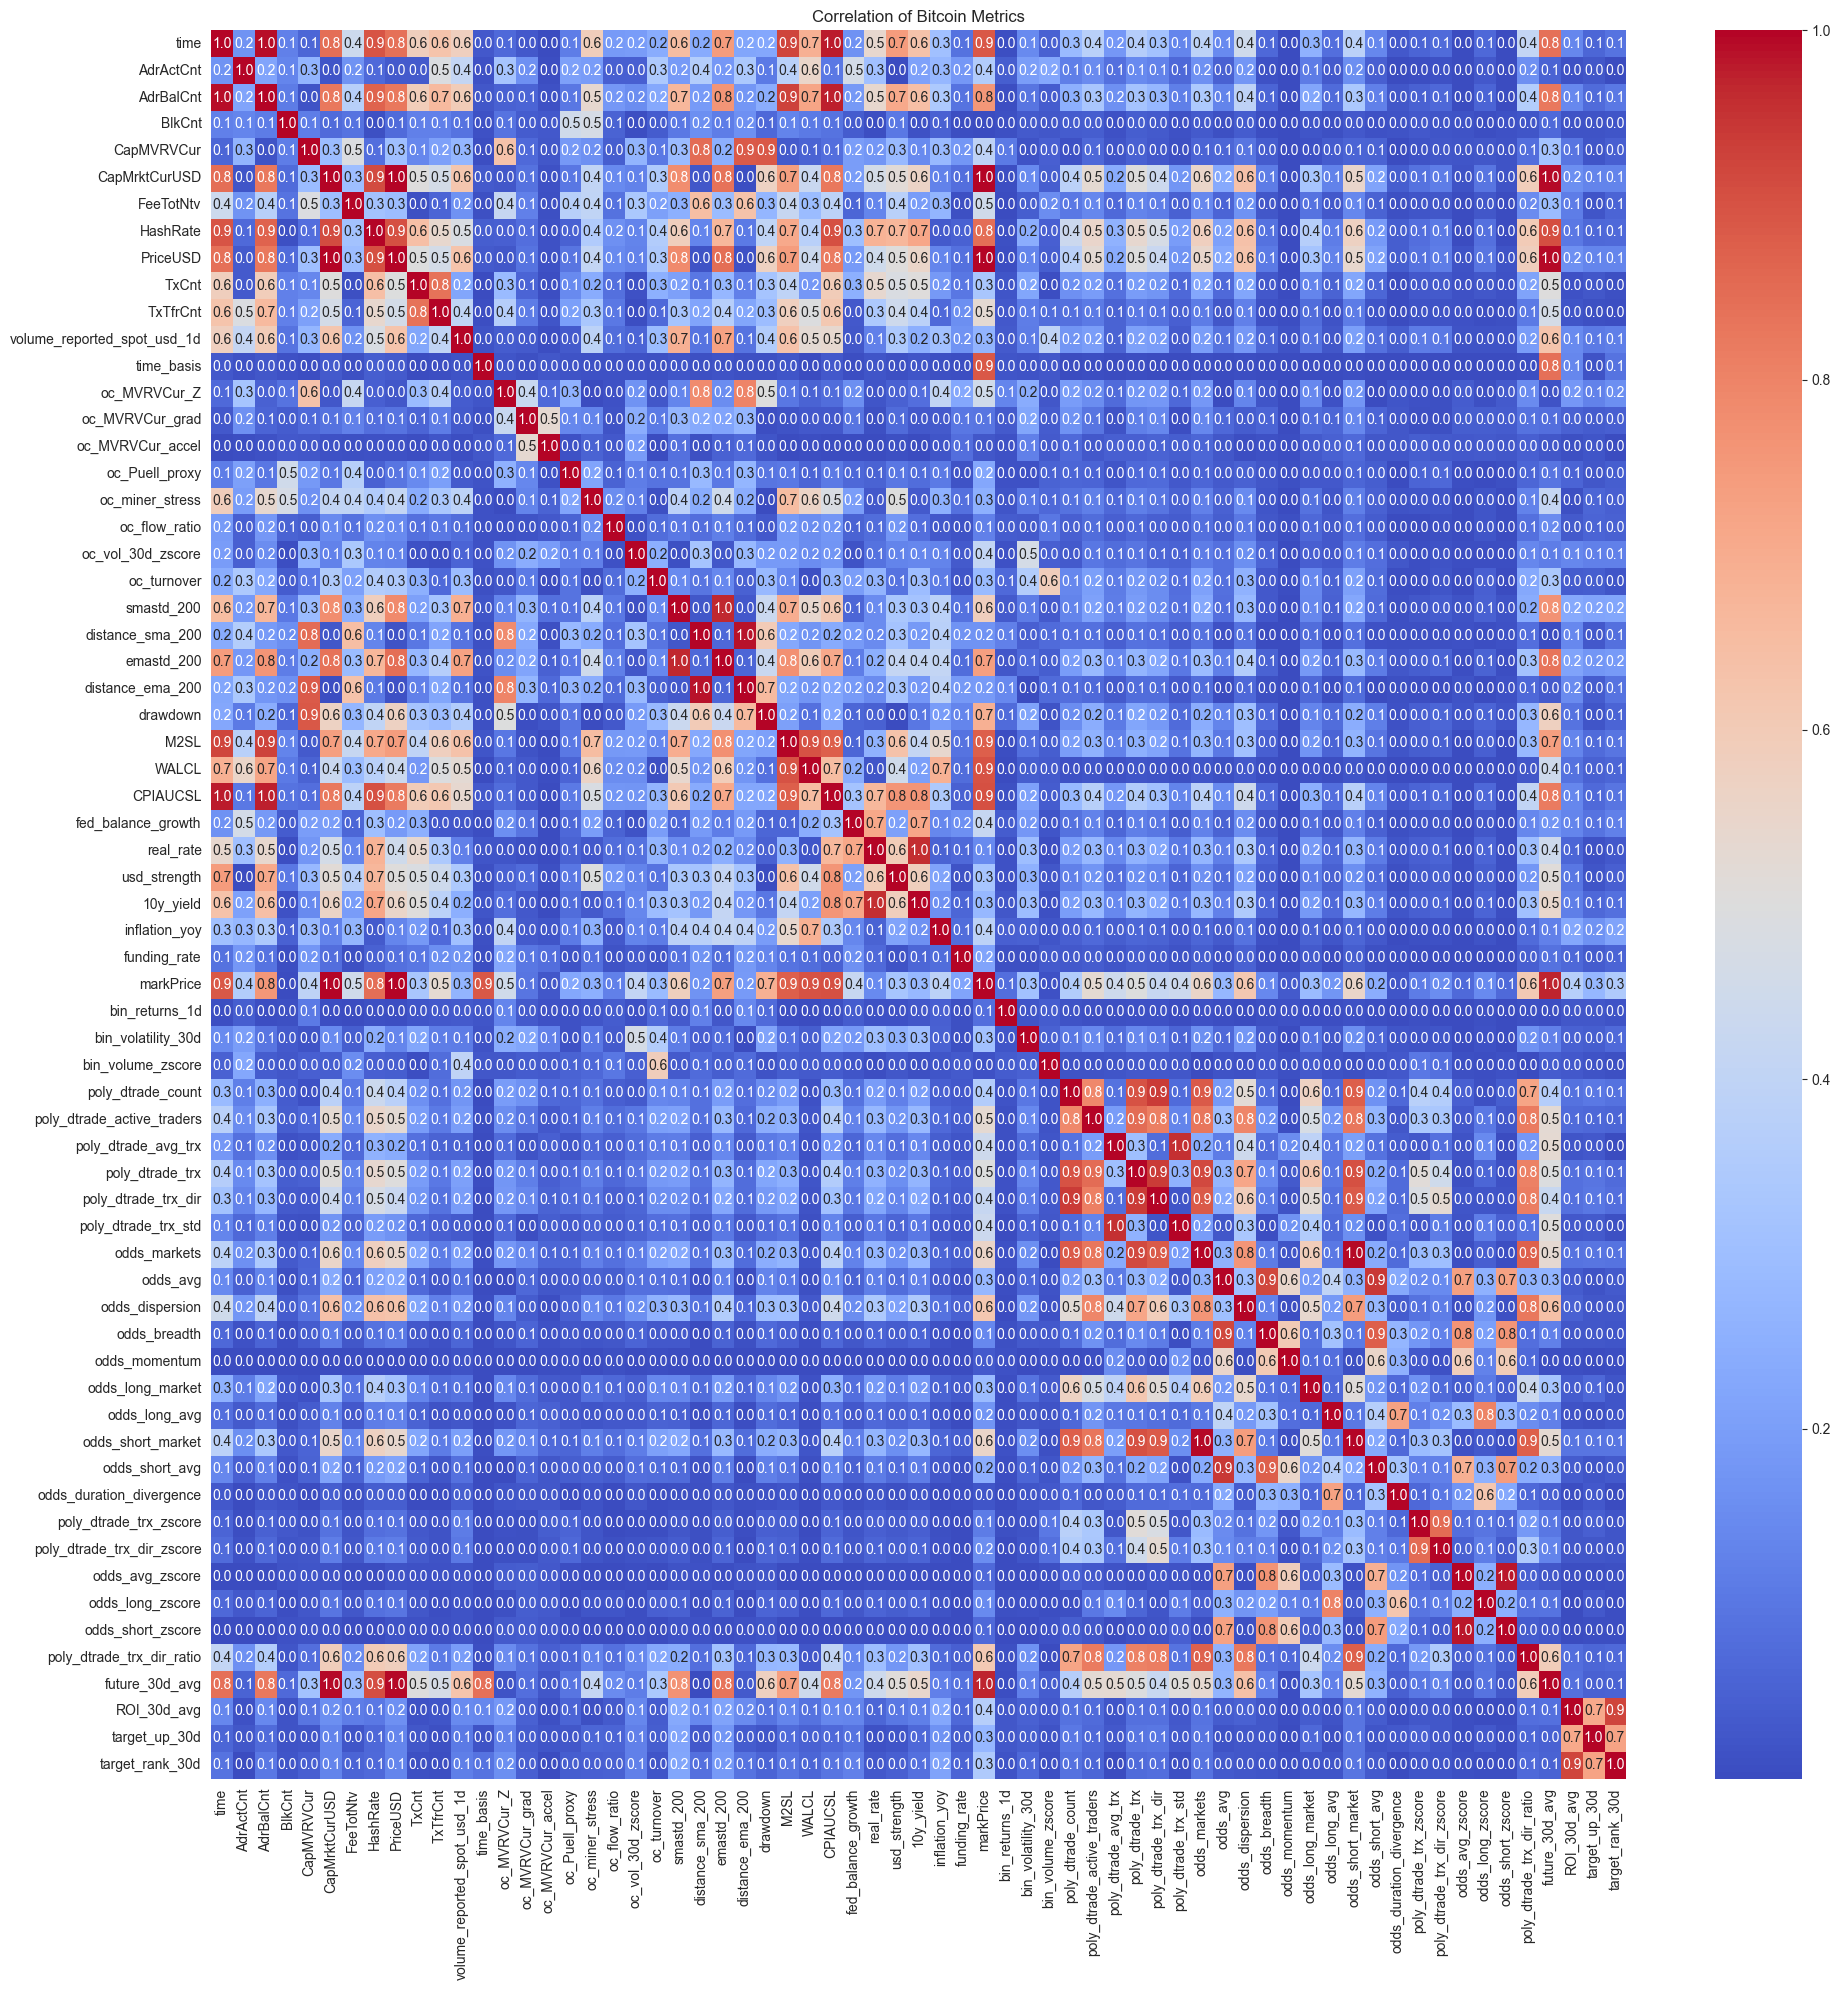

In [203]:
# Full correlation plot
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Correlation of Bitcoin Metrics")
plt.tight_layout()

In [134]:
COLS_TO_DROP = [
    'AssetCompletionTime',
    'AssetEODCompletionTime',
    'CapMrktEstUSD',
    'PriceBTC',
    'FlowInExNtv',
    'FlowInExUSD',
    'FlowOutExNtv',
    'FlowOutExUSD',
    'IssTotNtv',
    'IssTotUSD',
    'oc_flowimbalance',
    'oc_netexchangenorm',
    'oc_vol_30d',
    'ReferenceRate',
    'ReferenceRateETH',
    'ReferenceRateEUR',
    'ReferenceRateUSD',
    'ROI30d',
    'ROI1yr',
    'SplyCur',
    'SplyExNtv',
    'SplyExUSD',
    'SplyExpFut10yr',
    'open',
    'high',
    'low',
    'close',
    'volume',
    'close_time',
    'quote_volume',
    'trades',
    'taker_buy_base',
    'taker_buy_quote',
    'ignore',
    'symbol',
    'sma_200',
    'ema_200'
]

COLS_FILL_0 = [
    'funding_rate',
    'bin_returns_1d',
    'bin_volatility_30d',
    'bin_volume_zscore',
    'poly_dtrade_count',
    'poly_dtrade_active_traders',
    'poly_dtrade_avg_trx',
    'poly_dtrade_trx',
    'poly_dtrade_trx_dir',
    'poly_dtrade_trx_std',
    'odds_markets',
    'odds_dispersion',
    'odds_momentum',
    'odds_long_market',
    'odds_short_market',
    'odds_duration_divergence',
    'poly_dtrade_trx_zscore',
    'poly_dtrade_trx_dir_zscore',
    'odds_avg_zscore',
    'odds_long_zscore',
    'odds_short_zscore',
    'poly_dtrade_trx_dir_ratio',
    "oc_MVRVCur_Z",
    "oc_MVRVCur_grad",
    "oc_MVRVCur_accel",
    "oc_CapMrktCurUSD_Z",
    'oc_MVRVCur_vol_Z',
    "oc_vol_30d_Z",
    "distance_sma_200",
    "smastd_200",
    'RSI',
    'RSI_zscore'
]

COLS_FILL_05= [
    'odds_avg',
    'odds_breadth',
    'odds_long_avg',
    'odds_short_avg'
]

COLS_FILL_1 = [
    "oc_CapMrktCurUSD_Z",
    "oc_miner_stress",
    "oc_flow_ratio",
    "oc_Puell_proxy",
    'Future_60d_min_rel'

]

After all the feature creation, a total of 123 columns were present in the dataset. Most of the uninformative, redundant, or highly correlated features were removed, resulting in a dataset containing 5,659 rows and 86 columns (2 indices, 64 features, and 20 forward looking columns).

In [165]:
CU = help.CleanUp(btc_df)
CU.dropcol(COLS_TO_DROP)
CU.fill_zero(COLS_FILL_0)
CU.fill_05(COLS_FILL_05)
CU.fill_1(COLS_FILL_1)
btc_df_trunc = CU.df

In [166]:
btc_df_trunc.shape

(5659, 86)

In [136]:
# Identify columns with non-zero nulls
null_counts = btc_df_trunc.null_count()
cols_with_nulls = [
    col for col in null_counts.columns
    if null_counts[col].item() > 0
]

# Select only those columns from the null count result
result = null_counts.select(cols_with_nulls)
result.transpose(include_header=True)

column,column_0
str,u32
"""time_basis""",1
"""markPrice""",5078
"""ROI_30d""",30
"""ROI_30d_top30""",30
"""future_30d_avg""",29
…,…
"""future_60d_avg""",59
"""ROI_60d_avg""",59
"""future_60d_vs_30d_SMA""",89


In [137]:
btc_df_trunc.write_parquet("btc_df_final.parquet", compression="zstd")